In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('./results/pcg_comparison.csv')

METHODS   = ['MDS', 's_gd2', 'wrap_python', 'TorusMDS']
COLORS    = {'MDS': '#4C72B0', 's_gd2': '#DD8452', 'wrap_python': '#C44E52', 'TorusMDS': '#55A868'}
METRICS   = ['stress', 'distortion', 'sgs', 'np_score']
LABELS    = {
    'stress':     'Normalized stress',
    'distortion': 'Distortion',
    'sgs':        'SGS (Spearman rank corr.)',
    'np_score':   'Neighbourhood preservation',
    't_embed':    'Embedding time (s)',
}

data = {m: df[df['method'] == m] for m in METHODS}
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean','std']).round(4))


             stress         distortion             sgs         np_score  \
               mean     std       mean     std    mean     std     mean   
method                                                                    
MDS          0.3601  0.0384     0.2963  0.0329  0.5107  0.1506   0.4832   
TorusMDS     0.3212  0.0249     0.2607  0.0202  0.4530  0.1479   0.4804   
s_gd2        0.3676  0.0438     0.2967  0.0352  0.4718  0.1696   0.4362   
wrap_python  0.3617  0.0281     0.2890  0.0245  0.2410  0.1711   0.3963   

                    t_embed          
                std    mean     std  
method                               
MDS          0.1881  3.8419  4.7957  
TorusMDS     0.1839  0.9211  0.4216  
s_gd2        0.2094  0.0722  0.0852  
wrap_python  0.1833  0.9991  1.1229  


## Violin plots


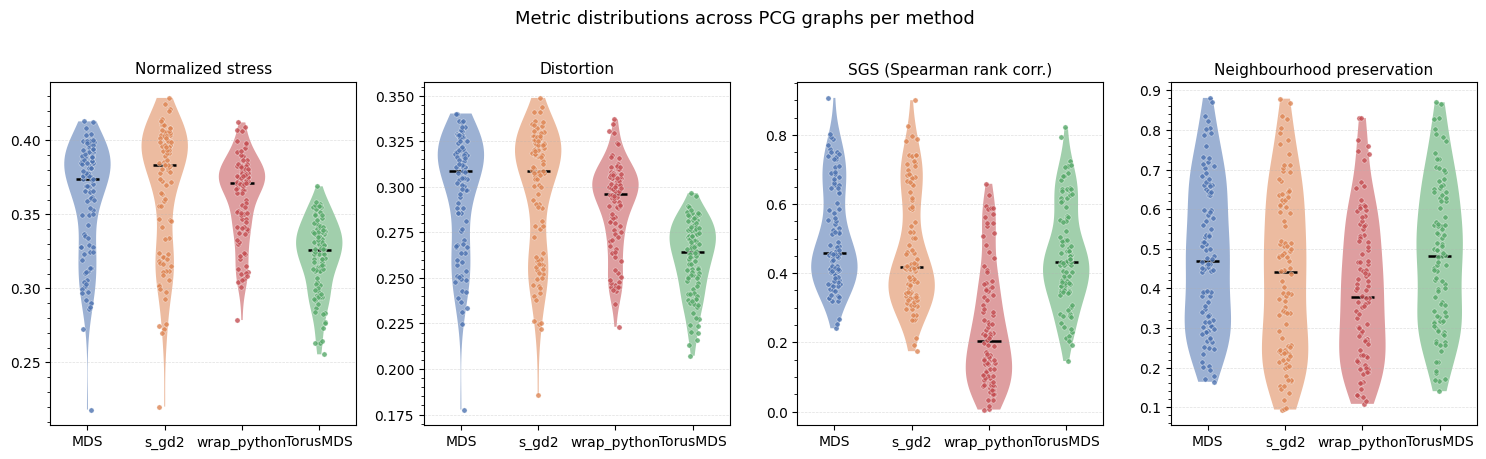

In [9]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=14, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.8)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)

fig.suptitle('Metric distributions across PCG graphs per method', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('./results/pcg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Metrics vs graph size n


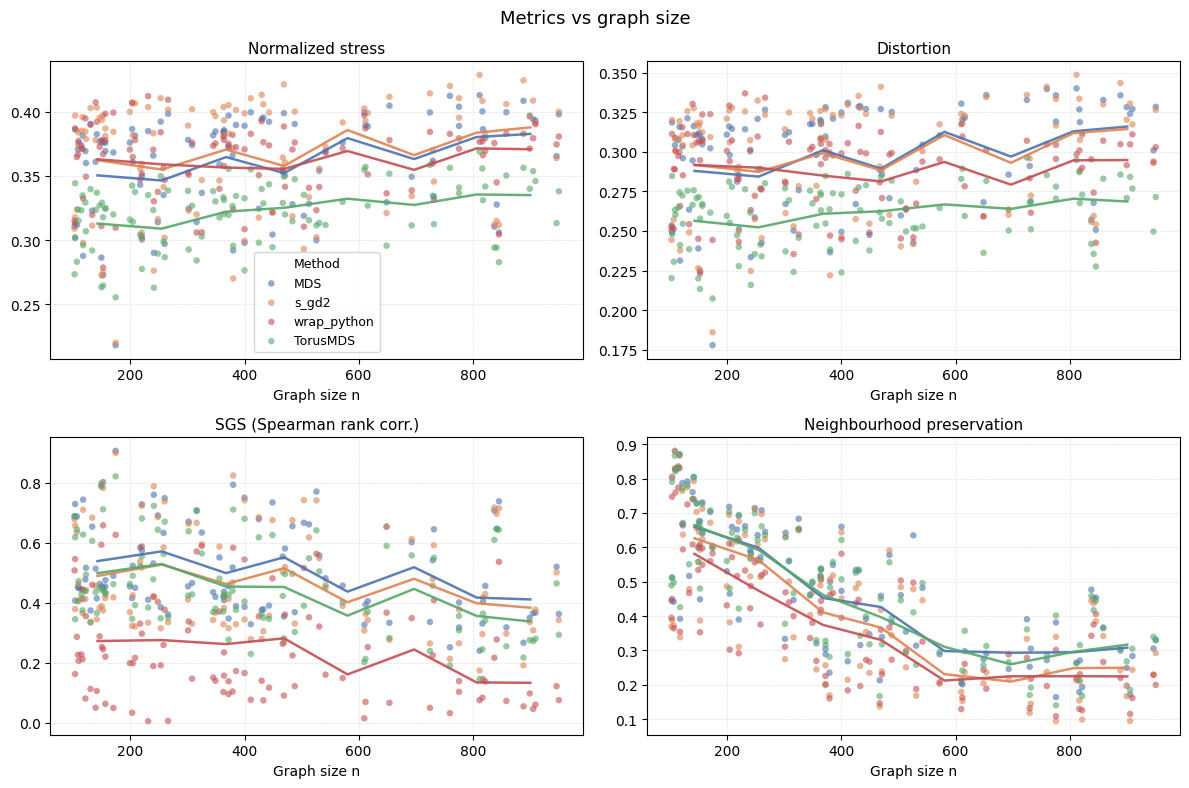

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=22, color=COLORS[m],
                   alpha=0.6, label=m, edgecolors='none')
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs graph size', fontsize=13)
fig.tight_layout()
plt.savefig('./results/pcg_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()


## Metrics vs attachment parameter m


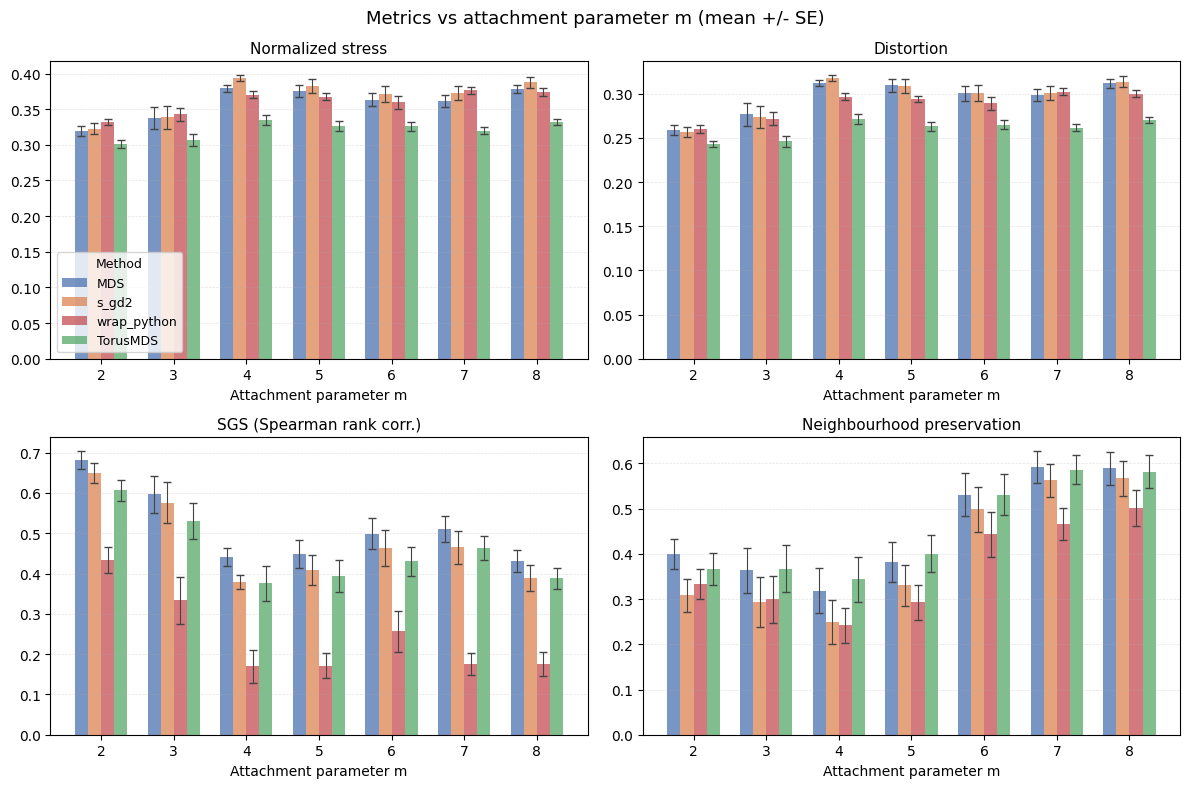

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
w = 0.18
ms = sorted(df['m'].unique())

for ax, metric in zip(axes.flat, METRICS):
    for xi, mth in enumerate(METHODS):
        means = [data[mth][data[mth]['m'] == m][metric].mean() for m in ms]
        sems  = [data[mth][data[mth]['m'] == m][metric].sem()  for m in ms]
        offsets = np.array(ms) + (xi - 1.5) * w
        ax.bar(offsets, means, width=w, color=COLORS[mth],
               alpha=0.75, label=mth, yerr=sems, capsize=3,
               error_kw=dict(elinewidth=0.8, ecolor='#444'))

    ax.set_xticks(ms)
    ax.set_xlabel('Attachment parameter m', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs attachment parameter m (mean +/- SE)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/pcg_metrics_vs_m.png', dpi=150, bbox_inches='tight')
plt.show()


## Metrics vs triangle probability p


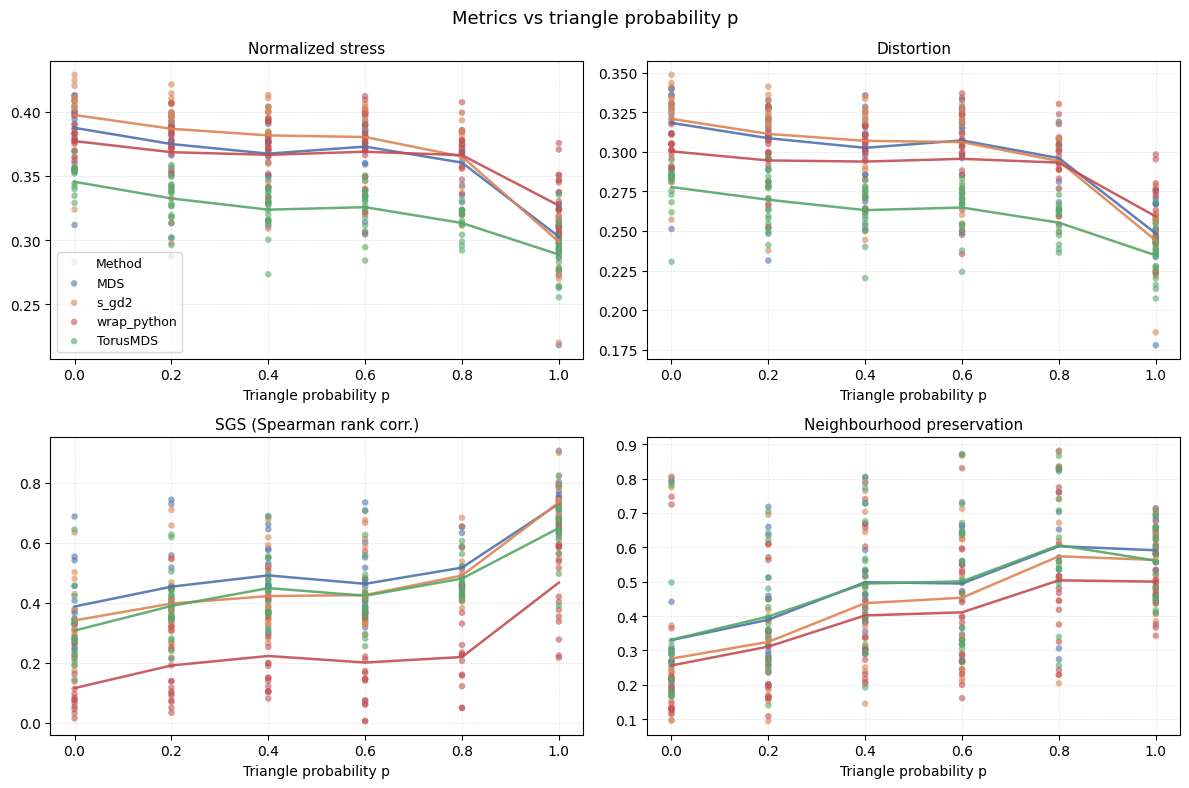

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, METRICS):
    for m in METHODS:
        d = data[m].sort_values('p')
        ax.scatter(d['p'], d[metric], s=22, color=COLORS[m],
                   alpha=0.6, label=m, edgecolors='none')
        trend = d.groupby('p', observed=True)[metric].mean()
        mids  = d.groupby('p', observed=True)['p'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Triangle probability p', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs triangle probability p', fontsize=13)
fig.tight_layout()
plt.savefig('./results/pcg_metrics_vs_p.png', dpi=150, bbox_inches='tight')
plt.show()


## Timing


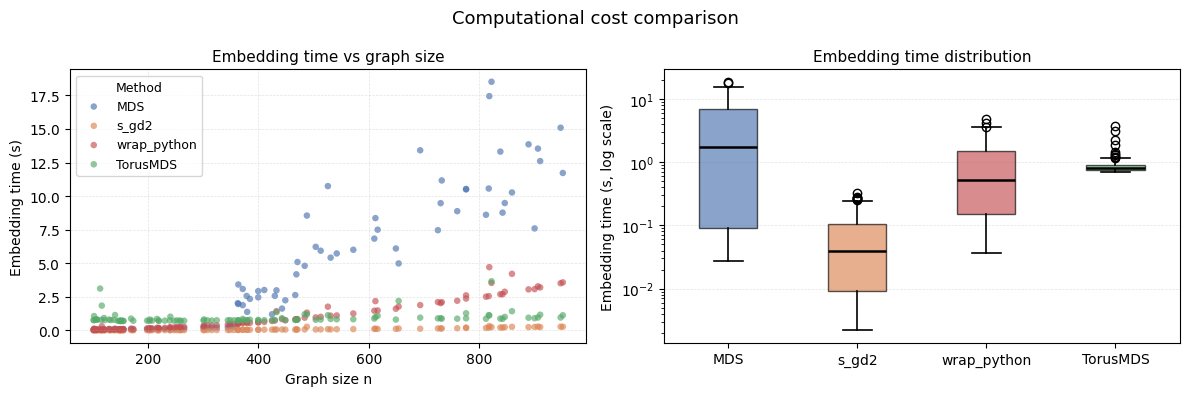

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=22, color=COLORS[m],
               alpha=0.65, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=9, title_fontsize=9)
ax.grid(linestyle='--', alpha=0.35)

ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison', fontsize=13)
fig.tight_layout()
plt.savefig('./results/pcg_timing.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary table


In [14]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.round(4)
summary


,stress_mean,stress_median,stress_std,distortion_mean,distortion_median,distortion_std,sgs_mean,sgs_median,sgs_std,np_score_mean,np_score_median,np_score_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,,,,,,,
MDS,0.3601,0.3739,0.0384,0.2963,0.3085,0.0329,0.5107,0.4571,0.1506,0.4832,0.4692,0.1881,3.8419,1.7481,4.7957
TorusMDS,0.3212,0.3257,0.0249,0.2607,0.2641,0.0202,0.4530,0.4335,0.1479,0.4804,0.4821,0.1839,0.9211,0.7930,0.4216
s_gd2,0.3676,0.3836,0.0438,0.2967,0.3086,0.0352,0.4718,0.4171,0.1696,0.4362,0.4409,0.2094,0.0722,0.0390,0.0852
wrap_python,0.3617,0.3711,0.0281,0.2890,0.2959,0.0245,0.2410,0.2031,0.1711,0.3963,0.3778,0.1833,0.9991,0.5197,1.1229
